In [10]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# ----------------------------------------------------------
# Load Data
# ----------------------------------------------------------

df = pd.read_csv("athlete_data.csv")  # replace with your filename
# Drop useless column
df = df.drop(columns=["Athlete_ID"])
df.head()




,Age,Gender,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator,heartbeat
0,24,Male,188,50,Low,12,2,1,3,7,3,5,5,4,Yes,83
1,37,Female,166,85,Medium,2,2,2,2,9,5,9,5,7,Yes,73
2,32,Female,188,75,High,12,2,3,2,9,9,4,8,8,No,64
3,28,Female,171,78,Medium,5,2,3,1,5,8,1,9,3,Yes,77
4,25,Male,175,70,Medium,12,1,0,6,1,2,4,9,9,No,78


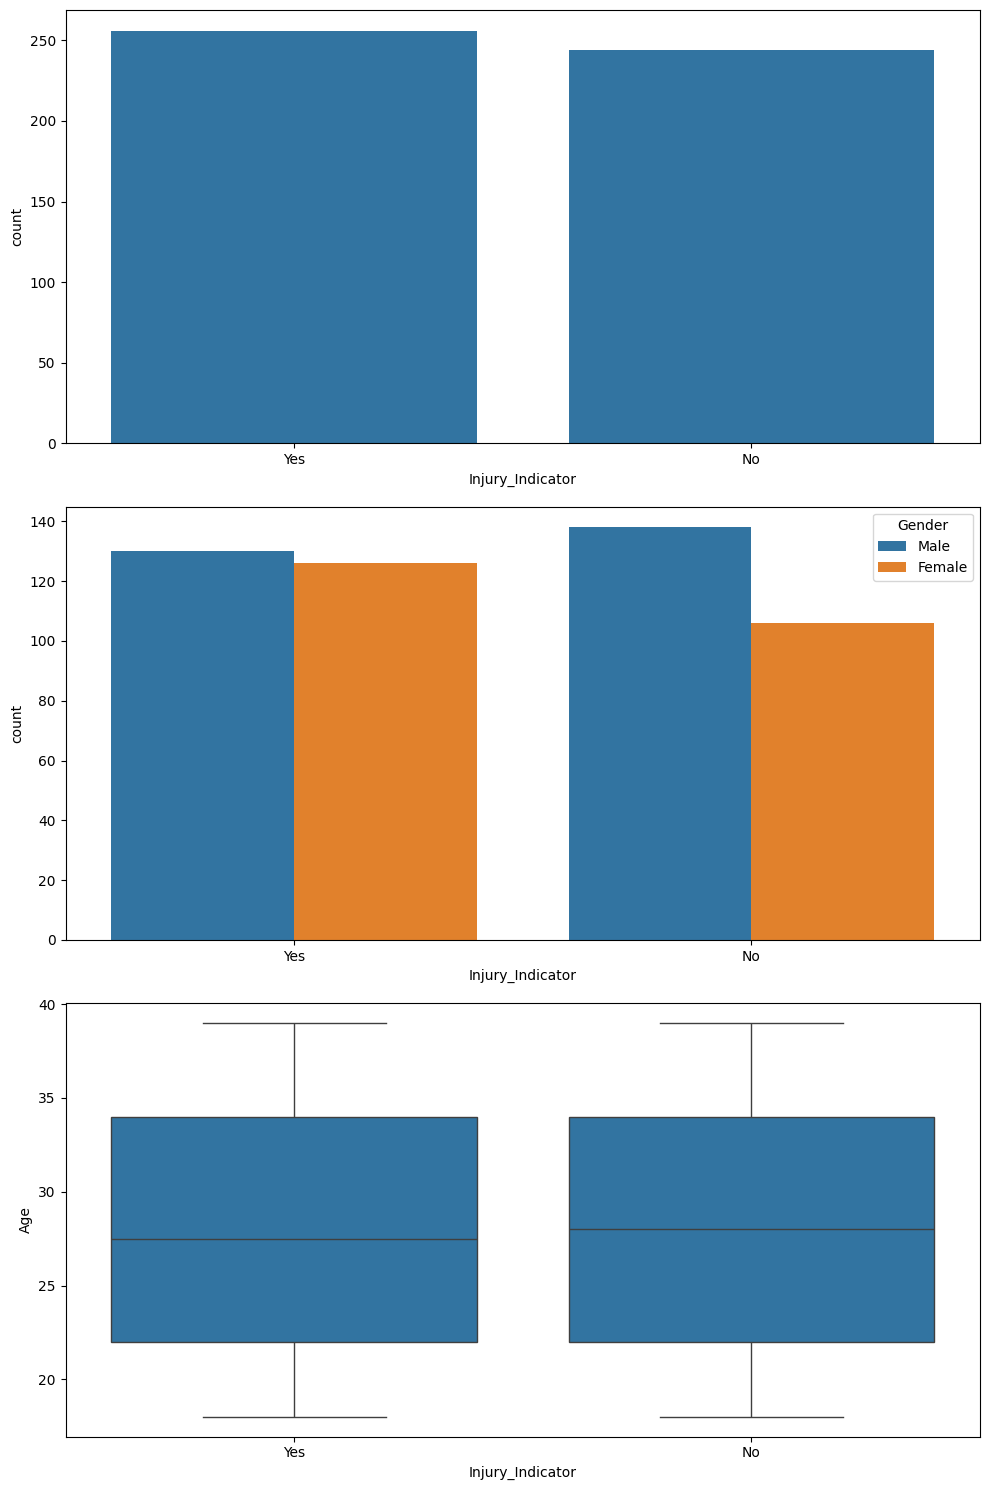

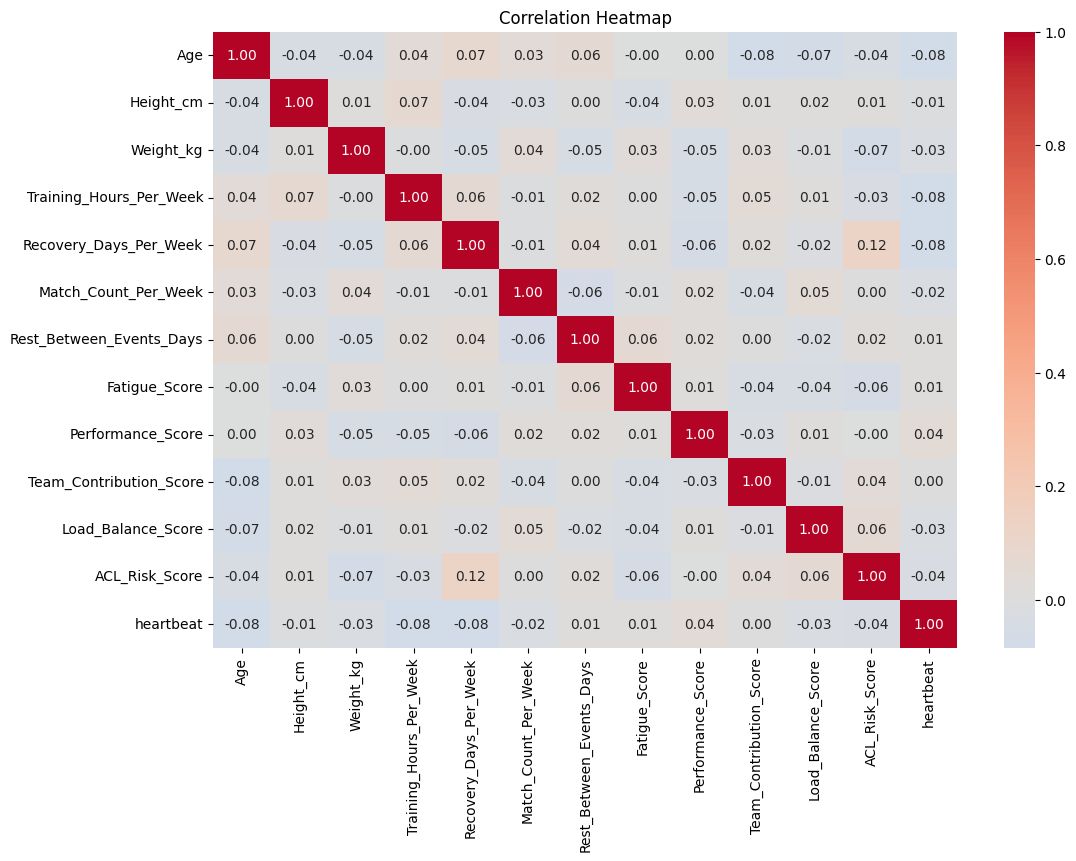

In [11]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 15)
)

sns.countplot(
    x="Injury_Indicator",
    data=df,
    ax=axes[0]
)

sns.countplot(
    x="Injury_Indicator",
    hue="Gender",
    data=df,
    ax=axes[1]
)

sns.boxplot(
    x="Injury_Indicator",
    y="Age",
    data=df,
    ax=axes[2]
)

plt.tight_layout()
plt.show()
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.show()


## Gender vs Injury

**Observation:** Female athletes exhibited a slightly higher injury rate than male athletes. However, the difference was modest, suggesting that gender alone is unlikely to be a strong predictor of injury.

## Age vs Injury

The boxplot comparing age distributions between injured and non-injured athletes showed substantial overlap.

**Observation:** The median age and overall distribution of ages were very similar for both groups. This suggests that age does not appear to be a strong standalone predictor of injury in this dataset.

## Correlation Analysis

A correlation heatmap was generated to investigate linear relationships between numerical features.

### Key Observations

- Most correlations were very close to zero.
- No pair of variables exhibited a strong positive or negative linear relationship.
- Variables such as **Fatigue_Score**, **Training_Hours_Per_Week**, and **heartbeat** showed little linear association with other features.

### Conclusion

The dataset contains weak linear relationships overall, suggesting that predicting injuries may require learning complex interactions between multiple variables rather than relying on a single dominant feature.

In [12]:
# Encode categorical columns
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

df["Injury_Indicator"] = df["Injury_Indicator"].map({
    "No": 0,
    "Yes": 1
})
df["Training_Intensity"] = df["Training_Intensity"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# features and target
X = df.drop(columns=["Injury_Indicator"])
y = df["Injury_Indicator"]

print(f"Dataset Shape: {df.shape}")
print(f"Features Shape: {X.shape}")
print(y.value_counts(normalize=True))


# split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))



Dataset Shape: (500, 16)
Features Shape: (500, 15)
Injury_Indicator
1    0.512
0    0.488
Name: proportion, dtype: float64
Model Accuracy: 0.53
              precision    recall  f1-score   support

           0       0.54      0.42      0.47        50
           1       0.52      0.64      0.58        50

    accuracy                           0.53       100
   macro avg       0.53      0.53      0.52       100
weighted avg       0.53      0.53      0.52       100



### Model Evaluation

The dataset contained 500 observations and 15 predictive features after preprocessing.

The target classes were nearly balanced, with 51.2% injured athletes and 48.8% non-injured athletes.

A Random Forest classifier achieved an accuracy of 53%, only slightly higher than the baseline accuracy of 51.2%.

The model demonstrated stronger performance in identifying injured athletes (recall = 0.64) than non-injured athletes (recall = 0.42).

Overall, the results suggest that the dataset contains limited predictive signal and that no strong relationship exists between the available features and injury occurrence.

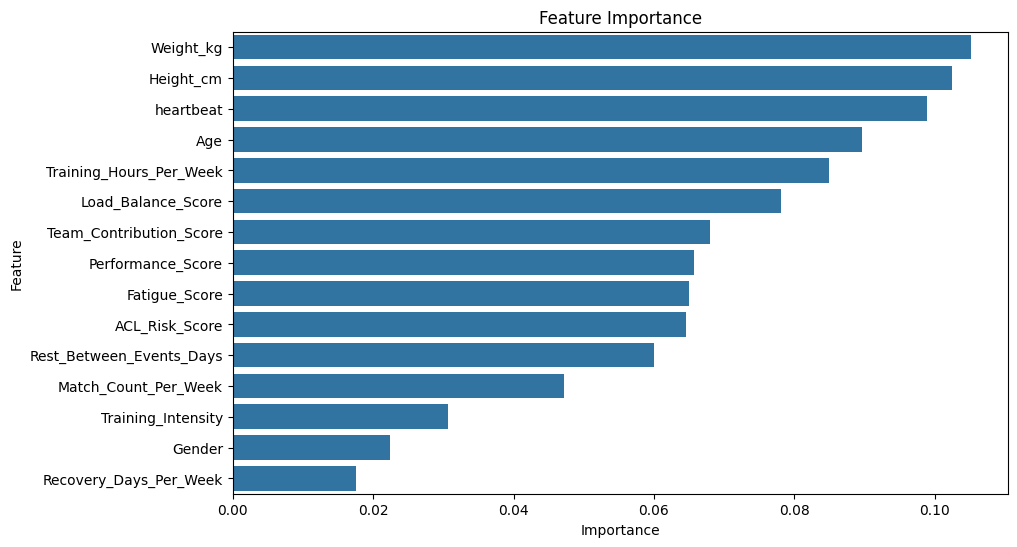

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

## Results

The Random Forest model achieved an accuracy of 53%.

Feature importance analysis showed that no single feature dominated the prediction process. The most important variables were Weight_kg, Height_cm, heartbeat, and Age.

The relatively low accuracy suggests that the dataset contains weak predictive signal or complex relationships that are difficult to capture using the available features.